# **MÓDULO 14 - Exercício**
# Pré Processamento dos Dados - A primeira etapa Pré Modelagem

Para nossa atividade usaremos uma base de churn também, porém essa base não diz respeito a serviços bancários e sim serviços de internet, telefone e tv - Telecomunicação.

Vamos realizar aqui as etapas de limpeza e tratamento de dados vistos durante a aula, porém aplicados a essa base nova.

In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import random

In [2]:
#Lembrem-se sempre de alterar a importação dos dados de acordo com o diretório de vocês.
df = pd.read_csv("CHURN_TELECON_MOD08_TAREFA.csv", delimiter=';')

df.head(10)

,customerID,Genero,Idoso,Casado,Dependents,Tempo_como_Cliente,PhoneService,Servico_Internet,Servico_Seguranca,Suporte_Tecnico,StreamingTV,Tipo_Contrato,PaymentMethod,Pagamento_Mensal,Total_Pago,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,DSL,No,No,No,Month-to-month,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,DSL,Yes,No,No,One year,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,DSL,Yes,No,No,Month-to-month,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,DSL,Yes,Yes,No,One year,Bank transfer (automatic),NaN,1840.75,No
4,9237-HQITU,NaN,0,No,No,2,Yes,Fiber optic,No,No,No,Month-to-month,Electronic check,NaN,151.65,Yes
5,9305-CDSKC,NaN,0,No,No,8,Yes,Fiber optic,No,No,Yes,Month-to-month,Electronic check,NaN,820.50,NaN
6,1452-KIOVK,NaN,0,No,Yes,22,Yes,Fiber optic,No,No,Yes,Month-to-month,Credit card (automatic),NaN,1949.40,NaN
7,6713-OKOMC,NaN,0,No,No,10,No,DSL,Yes,No,No,Month-to-month,Mailed check,NaN,301.90,NaN
8,7892-POOKP,NaN,0,Yes,No,28,Yes,Fiber optic,No,Yes,Yes,Month-to-month,Electronic check,NaN,3046.05,NaN
9,6388-TABGU,NaN,0,No,Yes,62,Yes,dsl,Yes,No,No,One year,Bank transfer (automatic),NaN,3487.95,NaN


Legenda dos dados:

*   **CustomerID** : Esse é o ID único de cada cliente nosso da rede de produtos de telecomunicação.

*   **Genero** : O genero dos nossos clientes.

*   **Idoso** : Se nosso cliente tem acima de 60 anos ou não. (Sim = 1 | Não = 0)

*   **Casado** : Se nosso cliente é casado ou não.

*   **Dependents** : Se cliente tem dependentes.

*   **Tempo_como_Cliente** : Tempo em meses que nosso cliente está com a nossa empresa.

*   **PhoneService** : Se ele contratou serviço telefônico com a nossa empresa.

*   **Servico_Internet** : Qual o tipo de serviço de internet contratado.

*   **Servico_Seguranca** : Se ele contratou serviço de segurança com a nossa empresa.

*   **Suporte_Tecnico** : Se já acionou o suporte técnico.

*   **StreamingTV** : Se ele contratou serviço de streaming para TV.

*   **Tipo_Contrato** : Qual o tipo de contrato dos nossos clientes, se era mensal, anual etc.

*   **PaymentMethod** : Forma de Pagamento.

*   **Pagamento_Mensal** : Quanto o cliente pagava mensalmente.

*   **Total_Pago** : Total já pago pelo cliente para nossa companhia.

*   **Churn** : Nossa coluna mais importante, se nosso cliente nos abandonou ou não.




# 1 - Carregue a base, verifique se os tipos de dados estão de acordo com cada coluna e caso não estejam realize a transformação dos tipos de dados.

In [3]:
#seu código aqui
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   customerID          2500 non-null   object 
 1   Genero              2488 non-null   object 
 2   Idoso               2500 non-null   int64  
 3   Casado              2500 non-null   object 
 4   Dependents          2500 non-null   object 
 5   Tempo_como_Cliente  2500 non-null   int64  
 6   PhoneService        1018 non-null   object 
 7   Servico_Internet    2500 non-null   object 
 8   Servico_Seguranca   2500 non-null   object 
 9   Suporte_Tecnico     2500 non-null   object 
 10  StreamingTV         2500 non-null   object 
 11  Tipo_Contrato       2500 non-null   object 
 12  PaymentMethod       2500 non-null   object 
 13  Pagamento_Mensal    2175 non-null   float64
 14  Total_Pago          2500 non-null   float64
 15  Churn               2495 non-null   object 
dtypes: flo

Todas as colunas parecem estar com o tipo correto. A única que me parece precisar de alteração é a Churn, essa coluna está com o tipo object e como ela é a coluna mais importante, o ideal seria ser do tipo booleana ou int (0 e 1). Então, inicialmente, irei transformar os 'No' em 0.0 e os 'Yes' em 1.0 (escolhe float pois há varios nan nessa coluna e eles são float) e depois quando eu for lidar com os nan passo tudo para int.

In [4]:
df['Churn'].unique()

array(['No', 'Yes', nan], dtype=object)

In [5]:
# Troco as string 'Yes' e 'No' pelos números 1 e 0 
df['Churn'] = df['Churn'].replace(['No','Yes'], [0,1])
df.head(10)

C:\Users\lucas\AppData\Local\Temp\ipykernel_16532\1816497136.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Churn'] = df['Churn'].replace(['No','Yes'], [0,1])


,customerID,Genero,Idoso,Casado,Dependents,Tempo_como_Cliente,PhoneService,Servico_Internet,Servico_Seguranca,Suporte_Tecnico,StreamingTV,Tipo_Contrato,PaymentMethod,Pagamento_Mensal,Total_Pago,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,DSL,No,No,No,Month-to-month,Electronic check,29.85,29.85,0.0
1,5575-GNVDE,Male,0,No,No,34,Yes,DSL,Yes,No,No,One year,Mailed check,56.95,1889.50,0.0
2,3668-QPYBK,Male,0,No,No,2,Yes,DSL,Yes,No,No,Month-to-month,Mailed check,53.85,108.15,1.0
3,7795-CFOCW,Male,0,No,No,45,No,DSL,Yes,Yes,No,One year,Bank transfer (automatic),NaN,1840.75,0.0
4,9237-HQITU,NaN,0,No,No,2,Yes,Fiber optic,No,No,No,Month-to-month,Electronic check,NaN,151.65,1.0
5,9305-CDSKC,NaN,0,No,No,8,Yes,Fiber optic,No,No,Yes,Month-to-month,Electronic check,NaN,820.50,NaN
6,1452-KIOVK,NaN,0,No,Yes,22,Yes,Fiber optic,No,No,Yes,Month-to-month,Credit card (automatic),NaN,1949.40,NaN
7,6713-OKOMC,NaN,0,No,No,10,No,DSL,Yes,No,No,Month-to-month,Mailed check,NaN,301.90,NaN
8,7892-POOKP,NaN,0,Yes,No,28,Yes,Fiber optic,No,Yes,Yes,Month-to-month,Electronic check,NaN,3046.05,NaN
9,6388-TABGU,NaN,0,No,Yes,62,Yes,dsl,Yes,No,No,One year,Bank transfer (automatic),NaN,3487.95,NaN


In [6]:
df.dtypes

customerID             object
Genero                 object
Idoso                   int64
Casado                 object
Dependents             object
Tempo_como_Cliente      int64
PhoneService           object
Servico_Internet       object
Servico_Seguranca      object
Suporte_Tecnico        object
StreamingTV            object
Tipo_Contrato          object
PaymentMethod          object
Pagamento_Mensal      float64
Total_Pago            float64
Churn                 float64
dtype: object

Pronto, agora todas as colunas estão com tipos ok!

# 2 - Esse exercício faremos por etapas:
A) Verifique se temos colunas com dados faltantes e traga a % dos dados faltantes por coluna.

In [7]:
# Quantidade de valores nulos por coluna
df.isnull().sum()

customerID               0
Genero                  12
Idoso                    0
Casado                   0
Dependents               0
Tempo_como_Cliente       0
PhoneService          1482
Servico_Internet         0
Servico_Seguranca        0
Suporte_Tecnico          0
StreamingTV              0
Tipo_Contrato            0
PaymentMethod            0
Pagamento_Mensal       325
Total_Pago               0
Churn                    5
dtype: int64

In [8]:
# Porcentagem de valores nulos por coluna
(df.isnull().sum() / len(df)) * 100

customerID             0.00
Genero                 0.48
Idoso                  0.00
Casado                 0.00
Dependents             0.00
Tempo_como_Cliente     0.00
PhoneService          59.28
Servico_Internet       0.00
Servico_Seguranca      0.00
Suporte_Tecnico        0.00
StreamingTV            0.00
Tipo_Contrato          0.00
PaymentMethod          0.00
Pagamento_Mensal      13.00
Total_Pago             0.00
Churn                  0.20
dtype: float64

Observa-se que as colunas 'PhoneService' e 'Pagamento_Mensal' possuem uma quantidade muito grande de dados faltantes enquanto que as colunas 'Genero' e 'Churn' possuem pouquíssimos dados nulos

B) Exclua nessa etapa as linhas das colunas com dados faltantes que você analisar que esse método é o ideal. Justifique o motivo de estar excluindo essas linhas.

In [9]:
#seu código aqui
df[df['Genero'].isnull()]

,customerID,Genero,Idoso,Casado,Dependents,Tempo_como_Cliente,PhoneService,Servico_Internet,Servico_Seguranca,Suporte_Tecnico,StreamingTV,Tipo_Contrato,PaymentMethod,Pagamento_Mensal,Total_Pago,Churn
4,9237-HQITU,NaN,0,No,No,2,Yes,Fiber optic,No,No,No,Month-to-month,Electronic check,NaN,151.65,1.0
5,9305-CDSKC,NaN,0,No,No,8,Yes,Fiber optic,No,No,Yes,Month-to-month,Electronic check,NaN,820.50,NaN
6,1452-KIOVK,NaN,0,No,Yes,22,Yes,Fiber optic,No,No,Yes,Month-to-month,Credit card (automatic),NaN,1949.40,NaN
7,6713-OKOMC,NaN,0,No,No,10,No,DSL,Yes,No,No,Month-to-month,Mailed check,NaN,301.90,NaN
8,7892-POOKP,NaN,0,Yes,No,28,Yes,Fiber optic,No,Yes,Yes,Month-to-month,Electronic check,NaN,3046.05,NaN
9,6388-TABGU,NaN,0,No,Yes,62,Yes,dsl,Yes,No,No,One year,Bank transfer (automatic),NaN,3487.95,NaN
10,9763-GRSKD,NaN,0,Yes,Yes,13,Yes,dsl,Yes,No,No,Month-to-month,Mailed check,NaN,587.45,0.0
11,7469-LKBCI,NaN,0,No,No,16,Yes,No,No internet service,No internet service,No internet service,Two year,Credit card (automatic),NaN,326.80,0.0
12,8091-TTVAX,NaN,0,Yes,No,58,Yes,Fiber optic,No,No,Yes,One year,Credit card (automatic),NaN,5681.10,0.0
13,0280-XJGEX,NaN,0,No,No,49,Yes,Fiber optic,No,No,Yes,Month-to-month,Bank transfer (automatic),NaN,5036.30,1.0


Veja só, curiosamente dentro das 12 linhas da coluna 'Genero' que possuem valor nulos estão as 5 linhas da coluna 'Churn' que possuem valor nulo. Como são poucas linhas em comparação à base total (0,48% em genero e 0,20% em Churn), irei excluir essas linhas.

Excluindo as linhas de Genero, as de Churn já serão excluidas também. Vou aproveitar e passar a coluna 'Churn' para int, algo que ficou faltando lá em cima.

In [10]:
# Excluindo:
df.dropna(subset=['Genero'], inplace=True)
df['Churn'].astype(int)
df.isnull().sum()

customerID               0
Genero                   0
Idoso                    0
Casado                   0
Dependents               0
Tempo_como_Cliente       0
PhoneService          1482
Servico_Internet         0
Servico_Seguranca        0
Suporte_Tecnico          0
StreamingTV              0
Tipo_Contrato            0
PaymentMethod            0
Pagamento_Mensal       313
Total_Pago               0
Churn                    0
dtype: int64

C) Nessa etapa substitua pela média, mediana ou moda as linhas das colunas com valores faltantes que você analisou e entendeu que esse era o melhor método. Não se esqueça de justificar sua escolha.

**Dica variáveis numéricas:** Não se esqueça de verificar a distrbuição dos dados, média e mediana.

**Dica variáveis categóricas:** Caso precise substituir uma variável categórica utilize um gráfico de barras para verificar a que mais aparece e utilizar ela na substituição.
Ou você pode optar por excluir a coluna, mas justifique sua escolha.

Caso opte por substituir você pode utilizar a função fillna:
df['SUACOLUNA'].fillna("VALOR QUE SUBSTITUIRA O NULO", inplace=True)
Ela funcionará como a replace.

------------

As colunas que escolhi para completar foram 'PhoneService' e 'Pagamento Mensal'. Como elas possuem muitos elementos nulos, não seria recomendado descartá-las.

A primeira coluna que vou tratar é a 'PhoneService'. Vamos ver qual a proporção entre 'Yes' e 'No'.

<Axes: xlabel='PhoneService', ylabel='Count'>

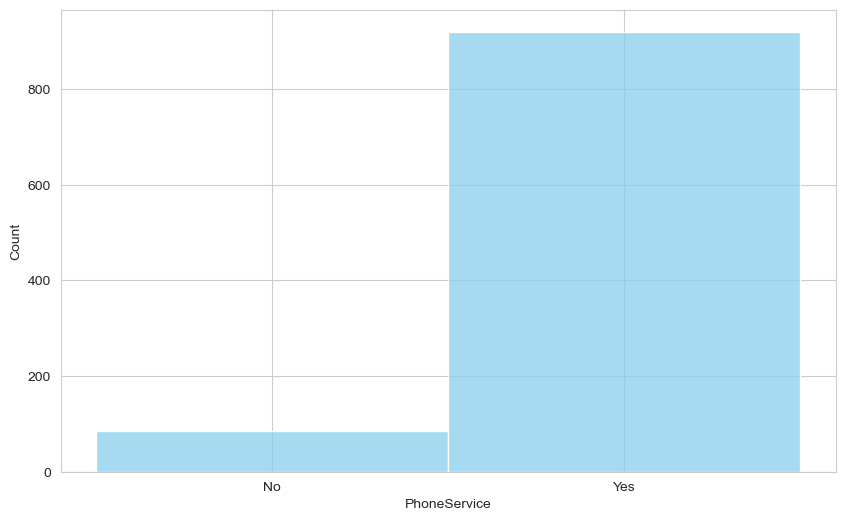

In [11]:
# é uma função da biblioteca Seaborn que define o estilo estético dos gráficos produzidos por Seaborn. Neste caso, 'whitegrid' é um dos estilos disponíveis em Seaborn
sns.set_style('whitegrid')

# Plota o boxplot da coluna de salário
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='PhoneService', bins=20, color='skyblue')

In [12]:
df['PhoneService'].value_counts(normalize=True) * 100

PhoneService
Yes    91.451292
No      8.548708
Name: proportion, dtype: float64

Abtive a informação de que o 'Yes' aparece 91,5% da vezes enquanto o 'No' aparece 8,5%. Nesse caso, por serem variáveis categóricas, não faz sentido aplicar a média ou mediana; apenas a moda é aplicável aqui. 

No entanto, farei algo diferente. Ao invés de simplesmente completar tudo com 'Yes' (que é a moda), irei inserir nos dados nulos 'Yes' e 'No' na mesma proporção (92% e 8%) de forma randomica.

In [13]:
# A função random.choices gera um vetor aleatório de 'Yes' e 'No' na proporção esperadoa de 0.92 e 0.08. k representa o tamanho do vetor, que no 
#  caso é a quantidade de valores nulos
lista_sim_nao = random.choices(['Yes', 'No'], weights=[0.92, 0.08], k=df['PhoneService'].isnull().sum())

# Essa função localiza todos os valores nulos da coluna 'PhoneService' e substitui pelo vetor gerado acima
df.loc[df['PhoneService'].isna(), 'PhoneService'] = lista_sim_nao

In [14]:
print('Número de valores nulos na coluna PhoneService: ',df['PhoneService'].isnull().sum())
df['PhoneService'].value_counts(normalize=True) * 100

Número de valores nulos na coluna PhoneService:  0


PhoneService
Yes    91.398714
No      8.601286
Name: proportion, dtype: float64

A coluna seguinte que vou tratar é a 'Pagamento_Mensal'. Vamos ver como seus valores estão distribuidos


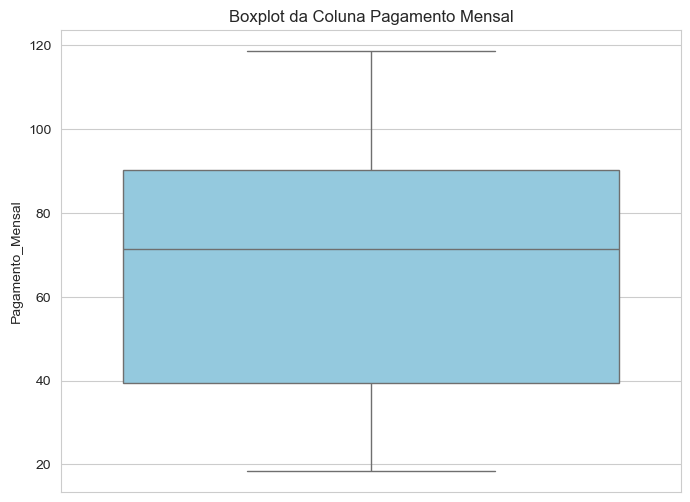

In [15]:
# é uma função da biblioteca Seaborn que define o estilo estético dos gráficos produzidos por Seaborn. Neste caso, 'whitegrid' é um dos estilos disponíveis em Seaborn
sns.set_style('whitegrid')

# Plota o boxplot da coluna de Pagamento Mensal
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, y='Pagamento_Mensal', color='skyblue')
plt.title('Boxplot da Coluna Pagamento Mensal')
plt.ylabel('Pagamento_Mensal')
plt.show()

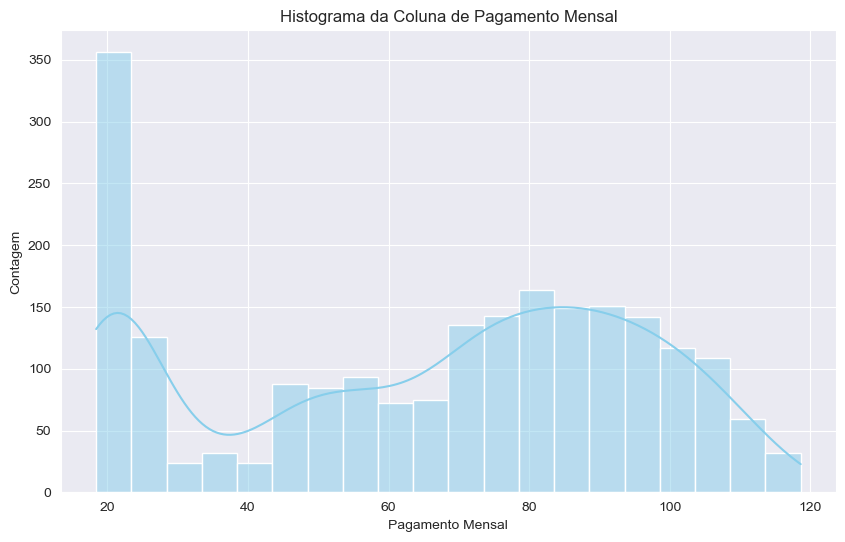

In [16]:
sns.set_style('darkgrid')

# Plotando um histograma dos Pagamento Mensal para analisarmos a distribuição dos dados
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='Pagamento_Mensal', bins=20, kde=True, color='skyblue')
plt.title('Histograma da Coluna de Pagamento Mensal')
plt.xlabel('Pagamento Mensal')
plt.ylabel('Contagem')
plt.show()

A partir dos gráficos é possível inferir que não há outliers no conjunto de dados. Então, para substituir os valores nulos, optei por usar a média

In [17]:
# Calcula a média dos salarios retirando os valores nulos do calculo
media_salario = df.loc[df['Pagamento_Mensal'].notna(), 'Pagamento_Mensal'].mean()

# Substitui os valores nulos pela média da coluna
df['Pagamento_Mensal'].fillna(media_salario, inplace=True)

C:\Users\lucas\AppData\Local\Temp\ipykernel_16532\355161771.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Pagamento_Mensal'].fillna(media_salario, inplace=True)


In [18]:
print('Número de valores nulos na coluna Pagamento_Mensal: ',df['Pagamento_Mensal'].isnull().sum())

Número de valores nulos na coluna Pagamento_Mensal:  0


# 3 - Verifique se encontramos valores digitados incorretamente, ou com letras maiusculas ou minusculas, ou até mesmo mesmos valores porém escritos de forma dirente e corrija.

Aqui a ideia é olhar os valores únicos das colunas e procurar se há valores parecidos que estão digitados errados

In [19]:
#seu código aqui
# Esse comando pd.unique puxa os valores únicos dos colunas passadas no argumento da função
pd.unique(df[['Genero', 'Idoso', 'Casado', 'Dependents', 'PhoneService', 'Servico_Internet', 'Servico_Seguranca', 'Suporte_Tecnico', 'StreamingTV',
              'Tipo_Contrato', 'PaymentMethod',]].values.ravel('K'))

array(['Female', 'Male', 'F', 'M', 'f', 0, 1, 'Yes', 'No', 'DSL',
       'Fiber optic', 'dsl', 'No internet service', 'Month-to-month',
       'One year', 'Two year', 'Electronic check', 'Mailed check',
       'Bank transfer (automatic)', 'Credit card (automatic)'],
      dtype=object)

Com o resultado acima, conclui-se que as colunas 'Genero' e 'Servico_Internet' possuem erros de digitação. As demais não apresentam problemas.

In [20]:
# Corrigindo a coluna 'Genero'
df['Genero'] = df['Genero'].replace('F', 'Female')
df['Genero'] = df['Genero'].replace('f', 'Female')
df['Genero'] = df['Genero'].replace('M', 'Male')
df['Genero'].unique()

array(['Female', 'Male'], dtype=object)

In [21]:
# Corrigindo a coluna 'Servico_Internet'
df['Servico_Internet'] = df['Servico_Internet'].replace('dsl', 'DSL')
df['Servico_Internet'].unique()

array(['DSL', 'No', 'Fiber optic'], dtype=object)

# [EXTRA] 4 - Caso deseje, para manter um padrão na sua base, renomeie as colunas ou deixando em português, ou inglês.

Vou renomear tudo para o Português

In [22]:
# Renomeando as colunas (Streaming )
df.rename(columns={'customerID': 'IDconsumidor'}, inplace=True)
df.rename(columns={'Dependents': 'Dependentes'}, inplace=True)
df.rename(columns={'PhoneService': 'Servico_Telefonia'}, inplace=True)
df.rename(columns={'StreamingTV': 'TV_assinatura'}, inplace=True)
df.rename(columns={'PaymentMethod': 'Metodo_Pagamento'}, inplace=True)

In [23]:
df = df.reset_index(drop=True)
df.head()

,IDconsumidor,Genero,Idoso,Casado,Dependentes,Tempo_como_Cliente,Servico_Telefonia,Servico_Internet,Servico_Seguranca,Suporte_Tecnico,TV_assinatura,Tipo_Contrato,Metodo_Pagamento,Pagamento_Mensal,Total_Pago,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,DSL,No,No,No,Month-to-month,Electronic check,29.850000,29.85,0.0
1,5575-GNVDE,Male,0,No,No,34,Yes,DSL,Yes,No,No,One year,Mailed check,56.950000,1889.50,0.0
2,3668-QPYBK,Male,0,No,No,2,Yes,DSL,Yes,No,No,Month-to-month,Mailed check,53.850000,108.15,1.0
3,7795-CFOCW,Male,0,No,No,45,No,DSL,Yes,Yes,No,One year,Bank transfer (automatic),65.607563,1840.75,0.0
4,8191-XWSZG,Female,0,No,No,52,Yes,No,No internet service,No internet service,No internet service,One year,Mailed check,65.607563,1022.95,0.0


In [25]:
#df.to_csv('CHURN_TELECON_MOD15_TAREFA.csv', index=False)